# K-Means Clustering -> PCR -> Logistic Regression

## Importing the libraries

In [162]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [163]:
dataset = pd.read_csv("Wine.csv")

In [164]:
# Same thing
# X = dataset.iloc[ : , 3:].values
wine_properties = dataset.iloc[ : , :].values # For discontinuous column

## Using the elbow method to find out the optimal number of clusters

In [165]:
from sklearn.cluster import KMeans

init="k-means++" is used to choose better starting centroids, so K-Means works faster and gives more stable, better clusters.

In [166]:
WCSS = []
for i in range(1,11):
  kmeans = KMeans(n_clusters= i , init = "k-means++", random_state = 42)
  kmeans.fit(wine_properties)
  WCSS.append(kmeans.inertia_)

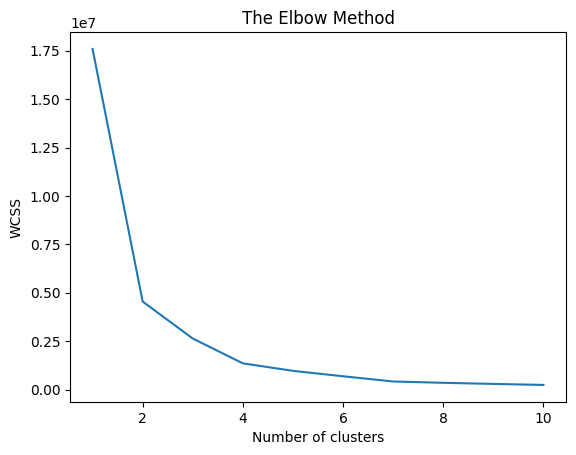

In [167]:
# plt.plot(x,y)
plt.plot(range(1, 11), WCSS)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

## Training the K_Means model on the datset

In [168]:
kmeans = KMeans(n_clusters=4, init = "k-means++", random_state= 42)
y_kmeans = kmeans.fit_predict(wine_properties)

In [169]:
print(y_kmeans)

[1 1 1 2 3 2 2 2 1 1 2 2 2 1 2 2 2 1 2 3 3 3 1 1 3 3 1 2 1 1 2 2 1 2 1 1 3
 1 1 3 3 1 1 3 3 1 1 1 1 2 1 2 1 2 1 1 1 2 2 0 3 0 3 0 0 3 0 0 3 3 3 0 0 1
 3 0 0 0 3 0 0 3 3 0 0 0 0 0 3 3 0 0 0 0 0 1 3 0 3 0 3 0 0 0 3 0 0 0 0 3 0
 0 3 0 0 0 0 0 0 0 3 0 0 0 0 0 0 0 0 0 3 0 0 3 3 3 3 0 0 3 3 3 0 0 3 3 0 3
 3 0 0 0 0 3 3 3 0 3 3 3 0 3 0 3 3 0 3 3 3 3 0 0 3 3 3 3 3 0]


Dimension Reduction process


## Adding the predictied column to the dataset

In [170]:
result = y_kmeans.reshape(len(y_kmeans), 1)

In [171]:
np.set_printoptions(suppress = True)
final_dataset =  np.concatenate((wine_properties, result), axis = 1)

In [172]:
#np.savetxt("final_dataset.csv", final_dataset, delimiter = ",")

## Importing the dataset

In [173]:
ds = pd.read_csv("Wine_3_Clusters.csv")
X = ds.iloc[:, : -1].values
y = ds.iloc[:, -1].values

## Spliting the dataset into the Training and Test set

In [174]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0)

## Feature Scaling


In [175]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

## Applying PCA

In [176]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 3)
X_train = pca.fit_transform(X_train)
X_test = pca.transform(X_test)

## Training the Logistic Regression model on the Training set

In [177]:
from sklearn.linear_model import LogisticRegression
classifier = LogisticRegression(random_state = 0)
classifier.fit(X_train, y_train)

LogisticRegression(random_state=0)

We are doing logistic regression because, to predict new wine and which segment will it goes..
also need to do the pca for new one.. and the structure is ready.


## Making a confusion Matrix

In [178]:
from sklearn.metrics import confusion_matrix, accuracy_score
y_pred = classifier.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)
accuracy_score(y_test, y_pred)

[[14  0  0]
 [ 0 16  0]
 [ 0  0  6]]


1.0